In [13]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


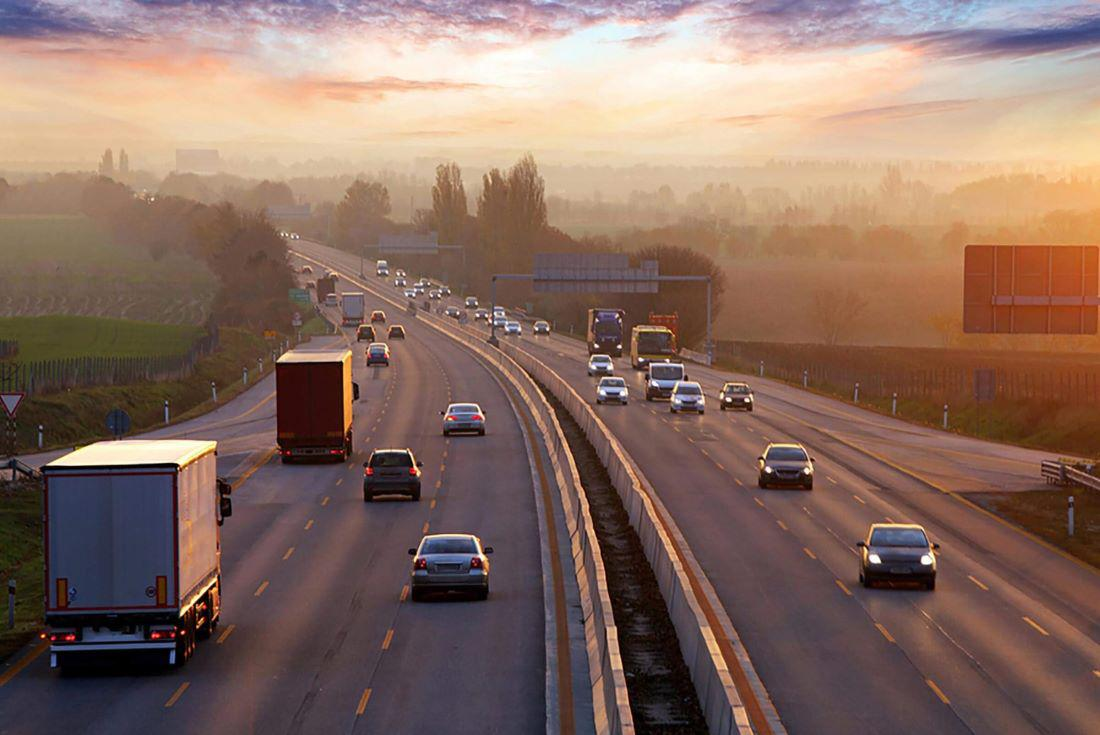

In [14]:
import cv2
from google.colab.patches import cv2_imshow
image_path = "/content/drive/My Drive/IPCV/image.jpg"
image = cv2.imread(image_path)
cv2_imshow(image)

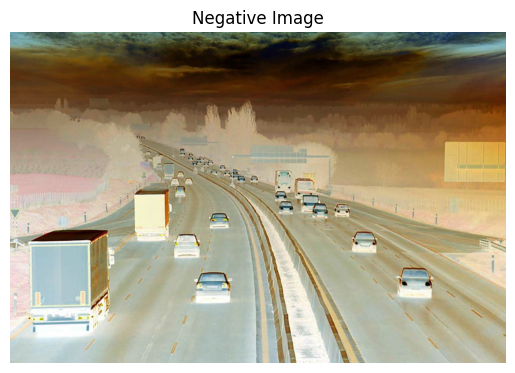

In [15]:
import matplotlib.pyplot as plt

L = 256
neg = (L - 1) - image

# 5. Displaying the Negative image
plt.imshow(neg)
plt.title("Negative Image")
plt.axis('off')

plt.show()

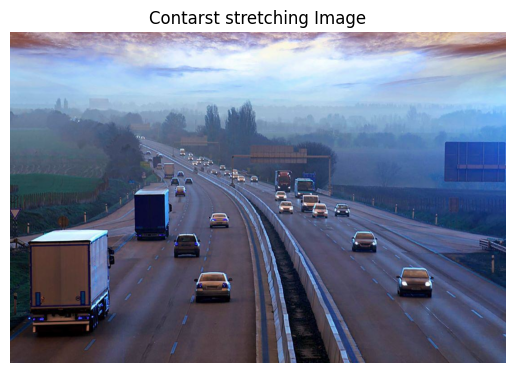

In [16]:
import numpy as np
rmin=np.min(image)
rmax=np.max(image)

contrast=(((image-rmin)/(rmax-rmin)*255)).astype(np.uint8)
plt.imshow(contrast)
plt.title("Contarst stretching Image")
plt.axis('off')

plt.show()

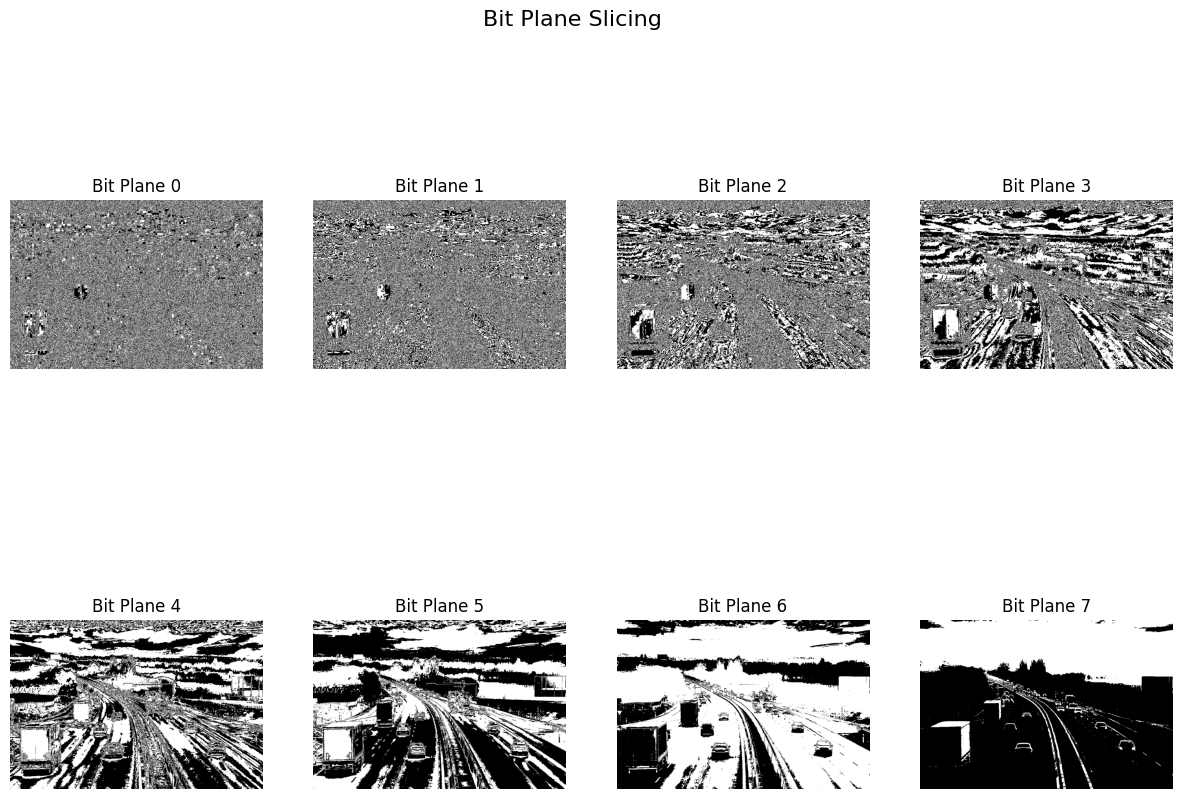

In [20]:
import numpy as np
import matplotlib.pyplot as plt
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
plt.figure(figsize=(15, 10))
plt.suptitle("Bit Plane Slicing", fontsize=16)

for i in range(8):
    bit_plane = ((gray_image >> i) & 1) * 255 # Multiply by 255 to make it visible (binary image)

    plt.subplot(2, 4, i + 1) # 2 rows, 4 columns, i+1-th subplot
    plt.imshow(bit_plane, cmap='gray')
    plt.title(f"Bit Plane {i}")
    plt.axis('off')
plt.show()

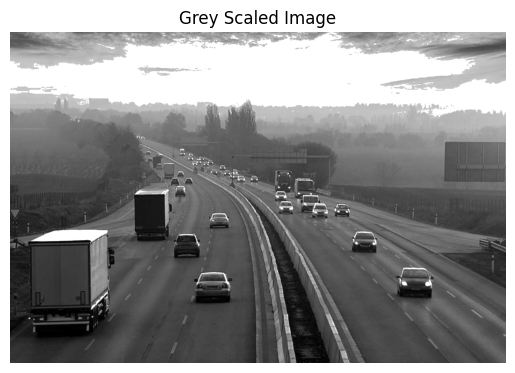

In [21]:
gray_image_gls = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

low_threshold = 200
high_threshold = 300
# Pixels within the range [low_threshold, high_threshold] are highlighted (e.g., set to 255),
# while pixels outside this range retain their original values.

sliced_with_bg = gray_image_gls.copy()
sliced_with_bg[(gray_image_gls >= low_threshold) & (gray_image_gls <= high_threshold)] = 255

plt.imshow(sliced_with_bg, cmap='gray')
plt.axis('off')
plt.title("Grey Scaled Image")

plt.show()